# Arrival Dynamics 1 — Short-Term Border Arrivals

This notebook shows how observations about a small number of daily refugee arrivals at a border crossing point can be turned into short-term planning forecasts during an unfolding influx situation.

The aim is not to predict a real emergency scenario with all its complexity. The data are synthetic, and the scenario is deliberately simplified. The purpose is to make the forecasting logic visible: what can be estimated from the information available at a given moment, what remains uncertain, and how different modelling assumptions can affect operational preparedness.

In many field settings, short-term planning is driven by simple averages and recent experience. That is often reasonable as a starting point. But mean-based, backward-looking estimates can hide important uncertainty. This notebook shows how the same basic information can be strengthened with simple probabilistic logic: not to produce certainty, but to make uncertainty explicit, quantify plausible ranges, and support better preparedness decisions.

We will follow a 30-day influx episode with synthetically generated data. The full episode exists in the background, but the notebook reveals it step by step. At each decision point, the analysis uses only the observations that would have been available to humanitarian teams at that time.

The scale of arrivals has been deliberately kept low so that the logic is easier to follow. The same ideas can be applied to larger operations; the numbers would change, but the reasoning remains the same.

## Scenario

A conflict escalation in a neighbouring country leads to increasing arrivals over several weeks. We will follow one particular border crossing point. Reception and registration teams need to decide how much capacity to prepare before the full scale of the movement is known.

During the first few days, the available observations suggest that arrivals are rising. But planners do not yet know whether the increase will stabilise, continue gradually, or develop into a larger surge.

## How the analysis is organised

The notebook is organised around decision points.

At each decision point, we will:

1. show the arrival observations available at that moment;
2. make a short-term forecast for the next planning horizon;
3. describe the uncertainty around that forecast;
4. reveal what actually happened only after the forecast has been made;
5. update the planning problem as new information becomes available.

The synthetic dataset contains internal fields used to construct the episode, but those fields are not used as planning information. The analysis works only with the arrival observations that would have been visible to humanitarian teams at the relevant point in time.

In [89]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt


CANONICAL_RELATIVE_PATH = Path("data/processed/arrival_dynamics_short_term_master.csv")

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / CANONICAL_RELATIVE_PATH).exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not find the project root from the current working directory.")

src_path = PROJECT_ROOT / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from forecasting.arrival_dynamics import (  # noqa: E402
    estimate_cautious_arrival_level,
    simulate_cautious_negative_binomial_forecast,
    summarize_preparedness_forecast_totals,
    translate_arrival_totals_to_preparedness,
    estimate_recent_arrival_level,
    mean_baseline_forecast,
    simulate_poisson_forecast,
    simulate_updated_negative_binomial_forecast,
    simulate_updated_poisson_forecast,
    summarize_forecast_totals_by_model,
    summarize_poisson_totals,
)
from operations.arrival_dynamics import (  # noqa: E402
    calculate_daily_backlog,
    calculate_daily_registration_capacity,
    simulate_backlog_by_staffing,
    summarize_backlog_risk,
    summarize_extended_stay_needs_by_staffing,
)


scenario = pd.read_csv(PROJECT_ROOT / CANONICAL_RELATIVE_PATH)

In [90]:
N_SIMULATIONS = 10_000

# Part I — First forecast under limited information

The first decision point occurs after five days of observations. Humanitarian teams need to prepare for the next week, but they do not yet know whether the early increase is temporary or the beginning of a larger movement.

The immediate question is simple:

**Given only the first five days of arrivals, what should planners expect for days 6–12?**

## 1. Initial observations: days 1–5

At the first decision point, only five daily arrival counts are available.

The observed arrivals are:

In [91]:
observed_days_1_5 = scenario.loc[
    scenario["day"].between(1, 5),
    ["day", "arrivals"],
].copy().reset_index(drop=True)

observed_days_1_5.rename(columns={"day": "Day", "arrivals": "Arrivals"}).style.hide(axis="index")

Day,Arrivals
1,25
2,40
3,44
4,48
5,69


These first five observations show an early upward signal. Daily arrivals increase from 25 on day 1 to 69 on day 5.

That is enough to raise concern. It is not enough to know the scale of what is coming. The next week could stabilise near the current level, continue increasing gradually, or move into a sharper surge.

At this point, the forecast should be understood as a planning estimate under limited information, not as a confident prediction of the next week.

## 2. A simple point forecast

A natural first step is to use the average of the observations so far.

Using days 1–5, the observed mean is:

In [92]:
observed_mean = observed_days_1_5["arrivals"].mean()
pd.DataFrame(
    {
        "Measure": ["Observed mean arrivals per day"],
        "Value": [observed_mean],
    }
).style.hide(axis="index")

Measure,Value
Observed mean arrivals per day,45.200000


This gives a simple daily forecast of **45.2 arrivals per day**.

For a seven-day planning horizon, this implies:

In [93]:
baseline_forecast = mean_baseline_forecast(observed_days_1_5)
baseline_total = baseline_forecast["forecast_total_arrivals"].iloc[0]

pd.DataFrame(
    {
        "Forecast start day": [baseline_forecast["day"].min()],
        "Forecast end day": [baseline_forecast["day"].max()],
        "Daily forecast arrivals": [baseline_forecast["forecast_arrivals"].iloc[0]],
        "Forecast horizon days": [baseline_forecast["forecast_horizon_days"].iloc[0]],
        "Forecast total arrivals": [baseline_total],
    }
).style.hide(axis="index")

Forecast start day,Forecast end day,Daily forecast arrivals,Forecast horizon days,Forecast total arrivals
6,12,45.200000,7,316.400000


The deterministic forecast for days 6–12 is therefore **316.4 arrivals** in total.

This is a useful baseline because it is transparent and easy to explain. But it has an important limitation: it gives only one number.

A point forecast does not show how much arrivals might vary around the estimate. It also does not protect against a deeper problem: the early average may stop being a reasonable guide if the underlying arrival level changes.

## 3. Adding uncertainty with a Poisson forecast

The next step is to represent uncertainty around the initial rate estimate.

Here we use a simple Poisson forecast. A Poisson model is often used for count data: situations where we are counting how many events occur in a fixed period. In this case, the “events” are daily arrivals, and the fixed period is one day.

We estimate the daily arrival rate from the first five days. Then, using a few lines of code, we simulate **many possible seven-day futures** for days 6–12. Each simulated future assumes that the early observed rate remains the best available estimate of the daily arrival level.

The daily arrival rate is estimated from the first five days:

In [94]:
poisson_simulations = simulate_poisson_forecast(
    observed_days_1_5,
    n_simulations=N_SIMULATIONS,
    seed=20240529,
)

pd.DataFrame(
    {
        "Measure": ["Estimated daily Poisson rate"],
        "Value": [observed_mean],
    }
).style.hide(axis="index")

Measure,Value
Estimated daily Poisson rate,45.200000


The Poisson simulation keeps the same basic expectation as the point forecast, but it shows how much the seven-day total might vary if the early observed rate remained a reasonable estimate for the next week.

The simulated seven-day totals are summarised below:

In [95]:
poisson_summary = summarize_poisson_totals(
    poisson_simulations,
    percentiles=(5, 25, 50, 75, 90, 95),
)
poisson_summary.rename(columns={"statistic": "Statistic", "value": "Value"}).style.hide(axis="index")

Statistic,Value
mean,316.543900
std,17.768721
min,259.000000
max,385.000000
p05,288.000000
p25,304.000000
p50,316.000000
p75,328.000000
p90,339.000000
p95,346.000000


Under this assumption, the simulated seven-day total is centred around about **316 arrivals**. The 5th to 95th percentile range is approximately **287 to 346 arrivals**.

In other words, if the early observed daily rate remained valid, most simulated futures would produce a seven-day total somewhere in that range. A total near 287 would be relatively low under this assumption, while a total near 346 would be relatively high. The point is not that arrivals will definitely fall inside this range. The point is that the range describes what ordinary random variation looks like under the initial rate assumption.

This is more informative than the point forecast alone. It tells planners that, if the early daily rate remains valid, ordinary random variation could still lead to somewhat lower or higher totals over the next week.

But the phrase **if the early daily rate remains valid** matters. This forecast represents uncertainty around the initial estimate. It does not account for a rapid change in the underlying arrival level.

## 4. Revealing the first forecast horizon: days 6–12

We now reveal what happened during the first forecast horizon.

The actual arrivals for days 6–12 were:

In [96]:
actual_days_6_12 = scenario.loc[
    scenario["day"].between(6, 12),
    ["day", "arrivals"],
].copy().reset_index(drop=True)

actual_days_6_12.rename(columns={"day": "Day", "arrivals": "Arrivals"}).style.hide(axis="index")

Day,Arrivals
6,96
7,106
8,101
9,83
10,136
11,188
12,148


The actual seven-day total was:

In [97]:
actual_total = actual_days_6_12["arrivals"].sum()
poisson_totals = poisson_simulations.groupby("simulation_id")["simulated_arrivals"].sum()
poisson_p95 = poisson_summary.loc[poisson_summary["statistic"] == "p95", "value"].iloc[0]
exceedance_count = int((poisson_totals >= actual_total).sum())
exceedance_rate = exceedance_count / len(poisson_totals)

forecast_comparison = pd.DataFrame(
    {
        "Measure": [
            "Deterministic baseline total",
            "Actual total",
            "Actual to baseline ratio",
            "Poisson 95th percentile total",
            "Poisson simulations at or above actual",
            "Poisson empirical exceedance rate",
        ],
        "Value": [
            baseline_total,
            actual_total,
            actual_total / baseline_total,
            poisson_p95,
            exceedance_count,
            exceedance_rate,
        ],
    }
)

forecast_comparison

,Measure,Value
0,Deterministic baseline total,316.400000
1,Actual total,858.000000
2,Actual to baseline ratio,2.711757
3,Poisson 95th percentile total,346.000000
4,Poisson simulations at or above actual,0.000000
5,Poisson empirical exceedance rate,0.000000


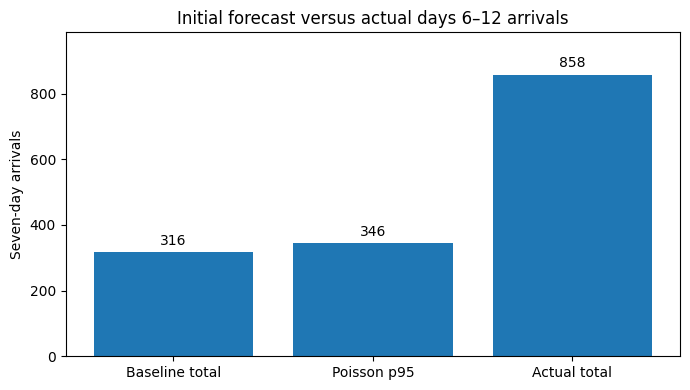

In [98]:
chart_data = pd.DataFrame(
    {
        "forecast_reference": [
            "Baseline total",
            "Poisson p95",
            "Actual total",
        ],
        "arrivals": [baseline_total, poisson_p95, actual_total],
    }
)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    chart_data["forecast_reference"],
    chart_data["arrivals"],
)

ax.set_ylabel("Seven-day arrivals")
ax.set_title("Initial forecast versus actual days 6–12 arrivals")
ax.bar_label(bars, fmt="%.0f", padding=3)
ax.set_ylim(0, max(chart_data["arrivals"]) * 1.15)

plt.tight_layout()

The result is far outside the initial forecast range.

The deterministic baseline forecast was **316.4 arrivals**. The actual total was **858 arrivals**, about **2.7 times** the baseline. It was also far above the 95th percentile of the initial Poisson forecast.

In the simulation, none of the simulated Poisson futures reached a total as high as the actual days 6–12 total.

This does not mean probabilistic forecasting was useless. The Poisson forecast did what it was asked to do: it described uncertainty around the early observed rate.

The problem was that the early observed rate quickly became outdated. After day 5, the arrival level changed sharply. The initial forecast failed mainly because the underlying arrival intensity increased, not because ordinary random fluctuation around the early rate was unusually large.

This distinction matters for the rest of the notebook.

A probabilistic forecast can show uncertainty around a stated assumption. But if the expected arrival level itself is changing, the forecast must be updated as new observations arrive.

At the next decision point, planners have seen days 1–12. The question is no longer whether the first five-day average is enough. The question becomes how to update the expected arrival level, and how much high-demand risk to plan for during the next high-pressure period.

# Part II — Updating the forecast under higher pressure

After days 6–12 are revealed, the planning problem changes.

The first forecast did not fail simply because ordinary random variation was large. It failed mainly because the arrival level moved sharply upward after day 5. The early five-day average was no longer a reasonable guide for the next planning horizon.

At the second decision point, planners have now seen arrivals for days 1–12. The next planning horizon is days 13–18.

The question is no longer:

**What should we expect if the first five days remain a good guide?**

The question is now:

**How should we update the expected arrival level, and how much high-demand risk should we plan for?**

## 5. What changed after the first reveal?

At this point, the visible arrival observations are:

In [99]:
observed_days_1_12 = scenario.loc[
    scenario["day"].between(1, 12),
    ["day", "arrivals"],
].copy().reset_index(drop=True)

observed_days_1_12.rename(columns={"day": "Day", "arrivals": "Arrivals"}).style.hide(axis="index")

Day,Arrivals
1,25
2,40
3,44
4,48
5,69
6,96
7,106
8,101
9,83
10,136


The difference between the first five days and the next seven days is substantial.

In [100]:
period_comparison = pd.DataFrame(
    {
        "Period": ["Days 1–5", "Days 6–12"],
        "Total arrivals": [
            observed_days_1_5["arrivals"].sum(),
            actual_days_6_12["arrivals"].sum(),
        ],
        "Mean daily arrivals": [
            observed_days_1_5["arrivals"].mean(),
            actual_days_6_12["arrivals"].mean(),
        ],
        "Maximum daily arrivals": [
            observed_days_1_5["arrivals"].max(),
            actual_days_6_12["arrivals"].max(),
        ],
    }
)

period_comparison.round(
    {
        "Total arrivals": 1,
        "Mean daily arrivals": 1,
        "Maximum daily arrivals": 1,
    }
)

,Period,Total arrivals,Mean daily arrivals,Maximum daily arrivals
0,Days 1–5,226,45.2,69
1,Days 6–12,858,122.6,188


The first five days had an average of 45.2 arrivals per day. During days 6–12, the average increased to about 122.6 arrivals per day.

This changes the planning picture. The early average was useful as a first reference point, but it should not continue to drive the forecast once the higher arrival level has become visible.

The recent observations also show uneven daily demand. Arrivals during days 6–12 ranged from 83 to 188 arrivals per day. That variation matters because planning is not only about the average number of arrivals. It is also about whether teams can cope with higher-demand days.

## 6. Updating the expected arrival level

For the next forecast, we use the most recent seven days as the update window.

In [101]:
update_window_days_6_12 = scenario.loc[
    scenario["day"].between(6, 12),
    ["day", "arrivals"],
].copy().reset_index(drop=True)

update_window_days_6_12.rename(columns={"day": "Day", "arrivals": "Arrivals"}).style.hide(axis="index")

Day,Arrivals
6,96
7,106
8,101
9,83
10,136
11,188
12,148


This is a simple choice. It gives more weight to the newly observed higher-pressure period and does not average it together with the earlier lower-arrival days.

Using days 6–12, the updated daily arrival level is:

In [102]:
recent_level = estimate_recent_arrival_level(observed_days_1_12)
updated_daily_mean = recent_level.loc[0, "updated_daily_arrival_level"]
recent_daily_std = recent_level.loc[0, "observed_sample_variance"] ** 0.5
recent_daily_cv = recent_level.loc[0, "observed_sample_cv"]

recent_level_table = pd.DataFrame(
    {
        "Measure": [
            "Updated daily mean",
            "Recent daily standard deviation",
            "Recent coefficient of variation",
        ],
        "Value": [updated_daily_mean, recent_daily_std, recent_daily_cv],
    }
)

recent_level_table.assign(
    Value=[
        round(updated_daily_mean, 1),
        round(recent_daily_std, 1),
        round(recent_daily_cv, 3),
    ]
)

,Measure,Value
0,Updated daily mean,122.6
1,Recent daily standard deviation,36.8
2,Recent coefficient of variation,0.3


The updated daily level is about 122.6 arrivals per day.

The recent daily standard deviation is about 36.8 arrivals per day. This means that recent daily arrivals have been quite uneven around the updated average. The coefficient of variation is about 0.30, which is another way of saying that the day-to-day variation is large relative to the average level.

These are not precise long-term estimates. They are planning signals from the information available at this point. The purpose is to update the forecast in a transparent way, while keeping the information boundary clear: days 13–18 are still unknown.

## 7. Comparing two uncertainty assumptions

We now compare two forecasts for days 13–18.

Both forecasts use approximately the same updated daily arrival level: 122.6 arrivals per day.

The difference is how much day-to-day variation they allow around that level.

The first forecast is an updated Poisson forecast. It uses the updated daily mean, but once that mean is fixed, the model allows only a relatively narrow amount of random variation around it. In a Poisson model, the variance is tied to the mean.

The second forecast is a Negative Binomial forecast. It keeps approximately the same expected daily level, but allows the variance to be larger than the mean. That makes it useful when recent arrivals look more uneven than a Poisson model would suggest.

Put simply:

- the Poisson forecast asks: what if arrivals fluctuate around the updated level in a relatively narrow way?
- the Negative Binomial forecast asks: what if the next period remains more uneven, like the recent observations suggest?

This is not a claim that the Negative Binomial model is the true arrival process. It is a planning assumption used to represent wider day-to-day uncertainty and examine upper-tail risk. It still does not solve the problem of trend or a further change in the arrival level.

In [103]:
updated_poisson_simulations = simulate_updated_poisson_forecast(
    observed_days_1_12,
    n_simulations=N_SIMULATIONS,
    seed=20240529,
)
updated_negative_binomial_simulations = simulate_updated_negative_binomial_forecast(
    observed_days_1_12,
    n_simulations=N_SIMULATIONS,
    seed=20240530,
)
updated_forecast_simulations = pd.concat(
    [updated_poisson_simulations, updated_negative_binomial_simulations],
    ignore_index=True,
)

model_assumptions = pd.DataFrame(
    {
        "Model": ["Updated Poisson", "Negative Binomial"],
        "Assumed daily mean": [updated_daily_mean, updated_daily_mean],
        "Assumed daily standard deviation": [
            updated_daily_mean ** 0.5,
            recent_daily_std,
        ],
        "Expected six-day total": [updated_daily_mean * 6, updated_daily_mean * 6],
    }
)

model_assumptions.round(
    {
        "Assumed daily mean": 1,
        "Assumed daily standard deviation": 1,
        "Expected six-day total": 1,
    }
)

,Model,Assumed daily mean,Assumed daily standard deviation,Expected six-day total
0,Updated Poisson,122.6,11.1,735.4
1,Negative Binomial,122.6,36.8,735.4


The two models have almost the same expected six-day total. The difference is the spread.

A Poisson forecast with a daily mean of about 122.6 implies a daily standard deviation of about 11.1 arrivals. The Negative Binomial forecast uses a daily standard deviation closer to the recent observed value, about 36.8 arrivals.

This difference is easier to see in the forecast ranges.

In [104]:
updated_forecast_summary = summarize_forecast_totals_by_model(
    updated_forecast_simulations,
    percentiles=(5, 50, 80, 90, 95),
)
model_labels = {
    "poisson_updated_level": "Updated Poisson",
    "negative_binomial_updated_level": "Negative Binomial",
}
summary_wide = (
    updated_forecast_summary.assign(
        Model=updated_forecast_summary["model"].map(model_labels)
    )
    .pivot(index="Model", columns="statistic", values="value")
    .reset_index()
)
interval_forecast_table = summary_wide[
    ["Model", "p05", "p50", "mean", "p95"]
].rename(
    columns={
        "p05": "5th percentile",
        "p50": "Median",
        "mean": "Mean",
        "p95": "95th percentile",
    }
)
interval_forecast_table = interval_forecast_table.set_index("Model").loc[
    ["Updated Poisson", "Negative Binomial"]
].reset_index()

interval_forecast_table.round(
    {
        "5th percentile": 1,
        "Median": 1,
        "Mean": 1,
        "95th percentile": 1,
    }
)

statistic,Model,5th percentile,Median,Mean,95th percentile
0,Updated Poisson,692.0,736.0,735.9,781.0
1,Negative Binomial,594.0,730.0,734.7,888.0


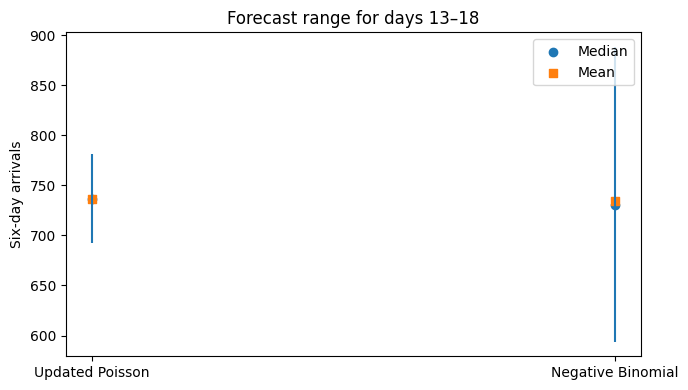

In [105]:
interval_chart_data = interval_forecast_table.copy()
x_positions = range(len(interval_chart_data))

fig, ax = plt.subplots(figsize=(7, 4))
ax.vlines(
    x=list(x_positions),
    ymin=interval_chart_data["5th percentile"],
    ymax=interval_chart_data["95th percentile"],
)
ax.scatter(list(x_positions), interval_chart_data["Median"], label="Median")
ax.scatter(list(x_positions), interval_chart_data["Mean"], marker="s", label="Mean")
ax.set_xticks(list(x_positions), interval_chart_data["Model"])
ax.set_ylabel("Six-day arrivals")
ax.set_title("Forecast range for days 13–18")
ax.legend()

plt.tight_layout()

The centres of the two forecasts are similar. Their ranges are not.

The Negative Binomial forecast has a wider lower tail and a wider upper tail. For preparedness, the upper tail is especially important, because it represents higher-demand outcomes that may strain reception, registration, information provision, and basic assistance capacity.

The upper-tail comparison is:

In [106]:
upper_tail_wide = summary_wide.set_index("Model")
upper_tail_comparison = pd.DataFrame(
    {
        "Percentile": ["80th percentile", "90th percentile", "95th percentile"],
        "Poisson total": [
            upper_tail_wide.loc["Updated Poisson", "p80"],
            upper_tail_wide.loc["Updated Poisson", "p90"],
            upper_tail_wide.loc["Updated Poisson", "p95"],
        ],
        "Negative Binomial total": [
            upper_tail_wide.loc["Negative Binomial", "p80"],
            upper_tail_wide.loc["Negative Binomial", "p90"],
            upper_tail_wide.loc["Negative Binomial", "p95"],
        ],
    }
)
upper_tail_comparison["Difference"] = (
    upper_tail_comparison["Negative Binomial total"]
    - upper_tail_comparison["Poisson total"]
)
upper_tail_comparison["NB / Poisson"] = (
    upper_tail_comparison["Negative Binomial total"]
    / upper_tail_comparison["Poisson total"]
)

upper_tail_comparison.round(
    {
        "Poisson total": 1,
        "Negative Binomial total": 1,
        "Difference": 1,
        "NB / Poisson": 3,
    }
)

,Percentile,Poisson total,Negative Binomial total,Difference,NB / Poisson
0,80th percentile,759.0,811.0,52.0,1.069
1,90th percentile,771.0,852.0,81.0,1.105
2,95th percentile,781.0,888.0,107.0,1.137


At the 95th percentile, the Negative Binomial forecast is about 107 arrivals higher than the Poisson forecast over the six-day horizon.

That difference is operationally meaningful. It does not change the expected number of arrivals very much. It changes what planners might consider a high but plausible demand level.

## 8. Revealing the high-pressure period: days 13–18

We now reveal what happened during the next forecast horizon.

The actual arrivals for days 13–18 were:

In [107]:
actual_days_13_18 = scenario.loc[
    scenario["day"].between(13, 18),
    ["day", "arrivals"],
].copy().reset_index(drop=True)

actual_days_13_18.rename(columns={"day": "Day", "arrivals": "Arrivals"}).style.hide(axis="index")

Day,Arrivals
13,151
14,234
15,167
16,193
17,164
18,137


The actual six-day total was:

In [108]:
actual_total_13_18 = actual_days_13_18["arrivals"].sum()
updated_forecast_totals = (
    updated_forecast_simulations.groupby(["model", "simulation_id"])[
        "simulated_arrivals"
    ]
    .sum()
    .reset_index(name="simulated_total_arrivals")
)

actual_comparison_rows = []
for model_key, model_label in model_labels.items():
    model_totals = updated_forecast_totals.loc[
        updated_forecast_totals["model"] == model_key,
        "simulated_total_arrivals",
    ]
    model_summary = upper_tail_wide.loc[model_label]
    median_total = model_summary["p50"]
    p95_total = model_summary["p95"]
    actual_comparison_rows.append(
        {
            "Model": model_label,
            "Median": median_total,
            "95th percentile": p95_total,
            "Actual total": actual_total_13_18,
            "Actual / median": actual_total_13_18 / median_total,
            "Actual / 95th percentile": actual_total_13_18 / p95_total,
            "Empirical exceedance probability": (
                model_totals >= actual_total_13_18
            ).mean(),
        }
    )

actual_comparison = pd.DataFrame(actual_comparison_rows)
actual_comparison.round(
    {
        "Median": 1,
        "95th percentile": 1,
        "Actual total": 1,
        "Actual / median": 3,
        "Actual / 95th percentile": 3,
        "Empirical exceedance probability": 3,
    }
)

,Model,Median,95th percentile,Actual total,Actual / median,Actual / 95th percentile,Empirical exceedance probability
0,Updated Poisson,736.0,781.0,1046,1.421,1.339,0.000
1,Negative Binomial,730.0,888.0,1046,1.433,1.178,0.001


The realised total was 1046 arrivals.

That is above the 95th percentile of both forecasts. It is also well above the forecast medians.

This result should be interpreted carefully.

The Negative Binomial forecast gave a wider upper tail than the Poisson forecast. It would have led to more cautious planning for high-demand outcomes. But it still did not fully capture the realised high-pressure total.

That does not make the comparison useless. It shows two things at once.

First, allowing for wider variability can materially change preparedness quantities. At the same expected level, the Negative Binomial forecast gave a much higher 95th percentile than the Poisson forecast.

Second, no single forecast made at one decision point removes the need for continued monitoring and updating. The situation is still developing, and the expected arrival level may continue to shift.

The lesson is not that one model is “true” and the other is “false.” The lesson is that model assumptions matter. A forecast is always conditional on what is known at the time and on the assumptions used to represent uncertainty.

The next step is to connect these forecast differences to operational planning. A difference of 100 or more arrivals in the upper tail may sound abstract, but it becomes more concrete when translated into reception pressure and overcrowding, registration workload and risk of backlog, or staffing and assistance needs.

# Part III — Updating, Preparedness and Operational Backlog Risk

The previous section showed that the high-pressure period exceeded both forecast ranges. That does not mean the forecasting exercise was useless. It means the forecast has to be updated again.

At this point, the notebook shifts from asking only **what might arrive next** to asking **what those possible arrivals imply for immediate operational preparedness**.

In a real operation, preparedness would not wait until this point. It would already have begun after the first arrivals were observed. For the purposes of this demonstration, however, we focus on preparedness here so that the logic is easier to follow. The same ideas can be applied earlier in the scenario as well.

The operational question now becomes sharper:

**How much response capacity should be prepared for the next phase?**

In this part, we first translate updated forecasts into immediate preparedness quantities. Then we move from total preparedness quantities to the more difficult question of daily throughput and unresolved backlog.

## 9. Updating after the high-pressure period

At this decision point, planners have seen arrivals through day 18.

In [109]:
actual_days_13_18 = scenario.loc[
    scenario["day"].between(13, 18),
    ["day", "arrivals"],
].copy().reset_index(drop=True)

actual_days_13_18.rename(columns={"day": "Day", "arrivals": "Arrivals"}).style.hide(axis="index")

Day,Arrivals
13,151
14,234
15,167
16,193
17,164
18,137


The most recent observations are still high, but they are also uneven. This makes it risky to assume that pressure has immediately stabilised.

We now use days 13–18 as the update window and forecast the next five days: days 19–23.

In [110]:
cautious_level_13_18 = estimate_cautious_arrival_level(
    scenario,
    observed_start_day=13,
    observed_end_day=18,
)

cautious_level_13_18_display = cautious_level_13_18.rename(
    columns={
        "updated_daily_arrival_level": "Updated daily mean",
        "recent_sample_sd": "Recent sample SD",
        "sd_floor": "SD floor",
        "assumed_daily_sd": "Assumed daily SD",
    }
)[
    [
        "Updated daily mean",
        "Recent sample SD",
        "SD floor",
        "Assumed daily SD",
    ]
]

cautious_level_13_18_display.round(1)


,Updated daily mean,Recent sample SD,SD floor,Assumed daily SD
0,174.3,34.7,43.6,43.6


The updated daily level is about **174.3 arrivals per day**.

The recent sample standard deviation is about **34.7 arrivals per day**. The cautious standard-deviation floor is slightly higher, about **43.6 arrivals per day**, so the forecast keeps a wider uncertainty range rather than assuming that volatility has already disappeared.

This is a preparedness choice. It is deliberately cautious after a volatile high-pressure period.

In [111]:
forecast_days_19_23_simulations = simulate_cautious_negative_binomial_forecast(
    scenario,
    observed_start_day=13,
    observed_end_day=18,
    forecast_start_day=19,
    forecast_end_day=23,
    n_simulations=N_SIMULATIONS,
    seed=20240531,
)

forecast_days_19_23_totals = summarize_preparedness_forecast_totals(
    forecast_days_19_23_simulations,
    percentiles=(50, 80, 95),
)

forecast_days_19_23_summary = forecast_days_19_23_totals.rename(
    columns={
        "forecast_reference": "Forecast reference",
        "forecast_total_arrivals": "Forecast total arrivals",
    }
)[["Forecast reference", "Forecast total arrivals"]]

forecast_days_19_23_summary.round({"Forecast total arrivals": 1}).style.hide(axis="index")

Forecast reference,Forecast total arrivals
p50,867.000000
p80,952.000000
p95,1036.000000


The forecast gives a typical five-day total of about **869 arrivals**, with a high-end preparedness reference around **1,038 arrivals** at the 95th percentile.

These totals can be translated into immediate preparedness quantities.

The following assumptions are illustrative. They are not universal humanitarian standards. They are used here to show how arrival forecasts can be converted into operational planning quantities. In a real response, preparedness assumptions would depend on applicable standards, the local context, available resources, and the intended response model.

In [112]:
preparedness_assumptions = pd.DataFrame(
    {
        "Planning quantity": [
            "Immediate water",
            "Immediate food",
            "Protection/information contact",
            "Protection contact capacity",
            "Medical readiness",
            "Registration workload",
        ],
        "Illustrative assumption": [
            "3 litres per arrival",
            "1 food unit per arrival",
            "1 brief contact per arrival",
            "60 contacts per staff-day",
            "1 team minimum; add 1 team per 250 average daily arrivals",
            "1 registration per arrival",
        ],
    }
)

preparedness_assumptions.style.hide(axis="index")

Planning quantity,Illustrative assumption
Immediate water,3 litres per arrival
Immediate food,1 food unit per arrival
Protection/information contact,1 brief contact per arrival
Protection contact capacity,60 contacts per staff-day
Medical readiness,1 team minimum; add 1 team per 250 average daily arrivals
Registration workload,1 registration per arrival


Using these assumptions, the forecast translates into the following immediate preparedness quantities.

In [113]:
preparedness_days_19_23 = translate_arrival_totals_to_preparedness(
    forecast_days_19_23_totals,
    forecast_horizon_days=5,
)

preparedness_days_19_23_display = preparedness_days_19_23.rename(
    columns={
        "forecast_reference": "Forecast reference",
        "forecast_total_arrivals": "Forecast total arrivals",
        "average_daily_arrivals": "Average daily arrivals",
        "immediate_water_litres": "Immediate water litres",
        "immediate_food_units": "Immediate food units",
        "protection_contacts": "Protection contacts",
        "protection_staff_days": "Protection staff-days",
        "registration_workload": "Registration workload",
        "medical_team_days": "Medical team-days",
    }
)[
    [
        "Forecast reference",
        "Forecast total arrivals",
        "Average daily arrivals",
        "Immediate water litres",
        "Immediate food units",
        "Protection contacts",
        "Protection staff-days",
        "Registration workload",
        "Medical team-days",
    ]
]

preparedness_days_19_23_display.round(
    {
        "Forecast total arrivals": 1,
        "Average daily arrivals": 1,
        "Immediate water litres": 1,
        "Immediate food units": 1,
        "Protection contacts": 1,
        "Registration workload": 1,
    }
).style.hide(axis="index")

Forecast reference,Forecast total arrivals,Average daily arrivals,Immediate water litres,Immediate food units,Protection contacts,Protection staff-days,Registration workload,Medical team-days
p50,867.000000,173.400000,2601.000000,867.000000,867.000000,15,867.000000,5
p80,952.000000,190.400000,2856.000000,952.000000,952.000000,16,952.000000,5
p95,1036.000000,207.200000,3108.000000,1036.000000,1036.000000,18,1036.000000,5


This table makes the operational effect of forecast uncertainty visible. Planning around the median is not the same as planning around the upper tail. The difference becomes water, food, protection and information-provision workload, registration workload, and medical team readiness.

We now reveal what actually happened during days 19–23.

In [114]:
actual_days_19_23 = scenario.loc[
    scenario["day"].between(19, 23),
    ["day", "arrivals"],
].copy().reset_index(drop=True)

actual_days_19_23.rename(columns={"day": "Day", "arrivals": "Arrivals"}).style.hide(axis="index")

Day,Arrivals
19,163
20,126
21,121
22,150
23,120


In [115]:
actual_total_19_23 = int(actual_days_19_23["arrivals"].sum())
assert actual_total_19_23 == 680

actual_days_19_23_comparison = forecast_days_19_23_summary.copy()
actual_days_19_23_comparison["Actual total"] = actual_total_19_23
actual_days_19_23_comparison["Actual minus forecast"] = (
    actual_days_19_23_comparison["Actual total"]
    - actual_days_19_23_comparison["Forecast total arrivals"]
)
actual_days_19_23_comparison["Actual / forecast"] = (
    actual_days_19_23_comparison["Actual total"]
    / actual_days_19_23_comparison["Forecast total arrivals"]
)

actual_days_19_23_comparison.round(
    {
        "Forecast total arrivals": 1,
        "Actual total": 1,
        "Actual minus forecast": 1,
        "Actual / forecast": 3,
    }
)


,Forecast reference,Forecast total arrivals,Actual total,Actual minus forecast,Actual / forecast
0,p50,867.0,680,-187.0,0.784
1,p80,952.0,680,-272.0,0.714
2,p95,1036.0,680,-356.0,0.656


The actual total for days 19–23 was **680 arrivals**.

That is below the cautious forecast median. In hindsight, the immediate post-surge forecast was conservative.

This is not a reason to discard the forecast logic. It shows the trade-off in preparedness planning. Immediately after a volatile high-pressure period, a cautious forecast may overstate the next few days if the situation begins to moderate. But the alternative risk is more serious: relaxing too quickly and under-preparing while pressure remains high.

The lesson is that forecast updates are not only technical adjustments. They express an operational posture toward uncertainty.

## 10. Planning for partial stabilisation

After days 19–23 are revealed, the planning picture changes again.

The recent observations are lower than the high-pressure period, but they are not low. The operation is still receiving substantial daily arrivals.

At this point, planners have seen arrivals through day 23. The final planning horizon is days 24–30.

In [116]:
actual_days_19_23.rename(columns={"day": "Day", "arrivals": "Arrivals"}).style.hide(axis="index")

Day,Arrivals
19,163
20,126
21,121
22,150
23,120


We now use days 19–23 as the update window and forecast days 24–30.

In [117]:
cautious_level_19_23 = estimate_cautious_arrival_level(
    scenario,
    observed_start_day=19,
    observed_end_day=23,
)

cautious_level_19_23_display = cautious_level_19_23.rename(
    columns={
        "updated_daily_arrival_level": "Updated daily mean",
        "recent_sample_sd": "Recent sample SD",
        "sd_floor": "SD floor",
        "assumed_daily_sd": "Assumed daily SD",
    }
)[
    [
        "Updated daily mean",
        "Recent sample SD",
        "SD floor",
        "Assumed daily SD",
    ]
]

cautious_level_19_23_display.round(1)


,Updated daily mean,Recent sample SD,SD floor,Assumed daily SD
0,136.0,19.4,34.0,34.0


The updated daily level is about **136.0 arrivals per day**.

The recent sample standard deviation is about **19.4 arrivals per day**. The cautious standard-deviation floor is **34.0 arrivals per day**, so the forecast again avoids assuming that uncertainty has collapsed just because the most recent window looks calmer.

In [118]:
forecast_days_24_30_simulations = simulate_cautious_negative_binomial_forecast(
    scenario,
    observed_start_day=19,
    observed_end_day=23,
    forecast_start_day=24,
    forecast_end_day=30,
    n_simulations=N_SIMULATIONS,
    seed=20240601,
)

forecast_days_24_30_totals = summarize_preparedness_forecast_totals(
    forecast_days_24_30_simulations,
    percentiles=(50, 80, 95),
)

forecast_days_24_30_summary = forecast_days_24_30_totals.rename(
    columns={
        "forecast_reference": "Forecast reference",
        "forecast_total_arrivals": "Forecast total arrivals",
    }
)[["Forecast reference", "Forecast total arrivals"]]

forecast_days_24_30_summary.round({"Forecast total arrivals": 1}).style.hide(axis="index")

Forecast reference,Forecast total arrivals
p50,948.000000
p80,1025.000000
p95,1108.000000


The typical seven-day forecast is about **949 arrivals**, with a 95th percentile preparedness reference of about **1,105 arrivals**.

Using the same immediate preparedness assumptions, this becomes:

In [119]:
preparedness_days_24_30 = translate_arrival_totals_to_preparedness(
    forecast_days_24_30_totals,
    forecast_horizon_days=7,
)

preparedness_days_24_30_display = preparedness_days_24_30.rename(
    columns={
        "forecast_reference": "Forecast reference",
        "forecast_total_arrivals": "Forecast total arrivals",
        "average_daily_arrivals": "Average daily arrivals",
        "immediate_water_litres": "Immediate water litres",
        "immediate_food_units": "Immediate food units",
        "protection_contacts": "Protection contacts",
        "protection_staff_days": "Protection staff-days",
        "registration_workload": "Registration workload",
        "medical_team_days": "Medical team-days",
    }
)[
    [
        "Forecast reference",
        "Forecast total arrivals",
        "Average daily arrivals",
        "Immediate water litres",
        "Immediate food units",
        "Protection contacts",
        "Protection staff-days",
        "Registration workload",
        "Medical team-days",
    ]
]

preparedness_days_24_30_display.round(
    {
        "Forecast total arrivals": 1,
        "Average daily arrivals": 1,
        "Immediate water litres": 1,
        "Immediate food units": 1,
        "Protection contacts": 1,
        "Registration workload": 1,
    }
).style.hide(axis="index")

Forecast reference,Forecast total arrivals,Average daily arrivals,Immediate water litres,Immediate food units,Protection contacts,Protection staff-days,Registration workload,Medical team-days
p50,948.000000,135.400000,2844.000000,948.000000,948.000000,16,948.000000,7
p80,1025.000000,146.400000,3075.000000,1025.000000,1025.000000,18,1025.000000,7
p95,1108.000000,158.300000,3324.000000,1108.000000,1108.000000,19,1108.000000,7


This is useful, but it is still incomplete.

A total-arrival forecast can tell us the scale of response to prepare. It can estimate water, food, protection and information-provision workload, medical readiness, and registration workload over the whole horizon.

But it does not yet answer the operational question that matters most for the next step:

**Can the team process arrivals day by day without unresolved cases accumulating?**

That depends on timing and capacity. A seven-day total may look manageable on average, while daily peaks still create backlog. The next section therefore turns the forecast into a registration-capacity problem.

## 11. Registration capacity and cumulative backlog

The previous section translated the forecast into immediate preparedness quantities. That is useful, but it still treats the planning horizon as a total.

For registration and reception management, totals are not enough. The timing of arrivals matters.

A team may be able to process the total number of people over a week in theory, but still face overcrowding if too many people arrive before they can be registered. This is where backlog becomes important.

In this notebook, we use a simple registration-capacity model:

In [120]:
registration_minutes_per_person = 15
operating_hours_per_day = 8
initial_backlog = 0
reception_capacity_threshold = 60
registrations_per_officer_per_day = calculate_daily_registration_capacity(officers=1)

registration_assumptions = pd.DataFrame(
    {
        "Assumption": [
            "Registration time",
            "Working day",
            "Capacity per officer",
            "Initial backlog",
            "Reception-capacity threshold",
        ],
        "Value": [
            "15 minutes/person",
            "8 hours",
            f"{registrations_per_officer_per_day} registrations/officer/day",
            "0 people",
            "60 unresolved people at end of day",
        ],
    }
)

registration_assumptions.style.hide(axis="index")

Assumption,Value
Registration time,15 minutes/person
Working day,8 hours
Capacity per officer,32 registrations/officer/day
Initial backlog,0 people
Reception-capacity threshold,60 unresolved people at end of day


Once again, these assumptions are illustrative. This is not a universal processing or registration model. The assumptions are used to show how forecast uncertainty can be translated into a concrete operational risk: unresolved people remaining at the reception point after daily processing.

The daily backlog calculation is recursive:

```text
available workload = starting backlog + new arrivals
processed registrations = min(available workload, daily registration capacity)
end-of-day backlog = available workload - processed registrations
```

If the end-of-day backlog is above the reception-capacity threshold, the site is treated as exceeding its safe unresolved-caseload level for this exercise. In other words, it represents a risk that the reception area becomes overcrowded.

Before using simulations, it helps to see the mechanism on a single staffing option of 4 registration officers.

In [121]:
forecast_path_totals = (
    forecast_days_24_30_simulations.groupby("simulation_id")["simulated_arrivals"]
    .sum()
    .reset_index(name="forecast_total_arrivals")
)
# Use the simulated path whose total arrivals are closest to the median total.
representative_total = forecast_path_totals["forecast_total_arrivals"].median()
representative_simulation_id = forecast_path_totals.loc[
    (forecast_path_totals["forecast_total_arrivals"] - representative_total).abs().idxmin(),
    "simulation_id",
]

representative_forecast_path = (
    forecast_days_24_30_simulations.loc[
        forecast_days_24_30_simulations["simulation_id"] == representative_simulation_id,
        ["day", "simulated_arrivals"],
    ]
    .rename(columns={"simulated_arrivals": "arrivals"})
    .reset_index(drop=True)
)

representative_staffing = 4
representative_backlog = calculate_daily_backlog(
    representative_forecast_path,
    officers=representative_staffing,
    initial_backlog=initial_backlog,
    reception_capacity_threshold=reception_capacity_threshold,
)

representative_backlog_display = representative_backlog.rename(
    columns={
        "day": "Day",
        "arrivals": "Simulated arrivals",
        "backlog_start": "Starting backlog",
        "processed_registrations": "Processed registrations",
        "backlog_end": "End-of-day backlog",
        "reception_capacity_exceeded": "Threshold exceeded",
    }
)[
    [
        "Day",
        "Simulated arrivals",
        "Starting backlog",
        "Processed registrations",
        "End-of-day backlog",
        "Threshold exceeded",
    ]
]

representative_backlog_display.style.hide(axis="index")

Day,Simulated arrivals,Starting backlog,Processed registrations,End-of-day backlog,Threshold exceeded
24,113,0,113,0,False
25,146,0,128,18,False
26,63,18,81,0,False
27,156,0,128,28,False
28,198,28,128,98,True
29,172,98,128,142,True
30,100,142,128,114,True


In this table, backlog is not recalculated independently each day. It carries forward. That is the key operational point. A difficult day can affect the next day even if arrivals later fall.

## 12. Probability of backlog and reception-capacity exceedance

We now apply the backlog calculation across the simulated forecast paths for days 24–30.

The staffing options are:

In [122]:
staffing_options = (3, 4, 5, 6, 7)

staffing_options_table = pd.DataFrame(
    {
        "officers": staffing_options,
        "daily_registration_capacity": [
            calculate_daily_registration_capacity(officers=officers)
            for officers in staffing_options
        ],
    }
)

staffing_options_table.rename(
    columns={
        "officers": "Officers",
        "daily_registration_capacity": "Daily registration capacity",
    }
).style.hide(axis="index")

Officers,Daily registration capacity
3,96
4,128
5,160
6,192
7,224


The question is not simply which option can process the median forecast. The question is how much backlog and overcrowding risk each option leaves under uncertainty.

In [123]:
forecast_days_24_30_backlog = simulate_backlog_by_staffing(
    forecast_days_24_30_simulations,
    staffing_options=staffing_options,
    initial_backlog=initial_backlog,
    reception_capacity_threshold=reception_capacity_threshold,
)

forecast_days_24_30_backlog_risk = summarize_backlog_risk(
    forecast_days_24_30_backlog
)

In [124]:
backlog_risk_display = forecast_days_24_30_backlog_risk.loc[
    :,
    [
        "officers",
        "daily_registration_capacity",
        "probability_any_backlog",
        "probability_reception_capacity_exceeded",
        "median_max_backlog",
        "p90_max_backlog",
        "probability_backlog_persists_at_horizon_end",
        "median_backlog_person_days",
        "p90_backlog_person_days",
    ],
].copy()

backlog_risk_display.round(3).rename(
    columns={
        "officers": "Officers",
        "daily_registration_capacity": "Daily registration capacity",
        "probability_any_backlog": "Probability of any backlog",
        "probability_reception_capacity_exceeded": "Probability threshold exceeded",
        "median_max_backlog": "Median maximum backlog",
        "p90_max_backlog": "p90 maximum backlog",
        "probability_backlog_persists_at_horizon_end": "Probability backlog persists",
        "median_backlog_person_days": "Median person-days",
        "p90_backlog_person_days": "90th pct. backlog person-days",
    }
).style.hide(axis="index")

Officers,Daily registration capacity,Probability of any backlog,Probability threshold exceeded,Median maximum backlog,p90 maximum backlog,Probability backlog persists,Median person-days,90th pct. backlog person-days
3,96,1.000000,0.998000,279.000000,398.000000,1.000000,1106.500000,1647.000000
4,128,0.995000,0.718000,94.000000,191.000000,0.888000,313.000000,779.000000
5,160,0.826000,0.146000,23.000000,70.000000,0.313000,31.000000,159.000000
6,192,0.339000,0.016000,0.000000,27.000000,0.062000,0.000000,30.000000
7,224,0.071000,0.001000,0.000000,0.000000,0.010000,0.000000,0.000000


The table shows a clear decision gradient.

With **3 officers**, backlog risk is essentially certain and the reception-capacity threshold is exceeded in almost all simulated paths. This option is clearly insufficient.

With **4 officers**, the operation has more capacity, but the risk remains high. The forecast still shows a substantial probability of exceeding the 60-person threshold.

With **5 officers**, the risk becomes more tolerable, though not zero. This is the first option that looks meaningfully protective against upper-tail pressure.

With **6 or 7 officers**, the risk becomes much lower under this forecast. These options may be appropriate if the operation has a low tolerance for overcrowding, but they also require more resources.

The point is not that the model tells us the “correct” number of officers. The point is that it makes the trade-off visible.

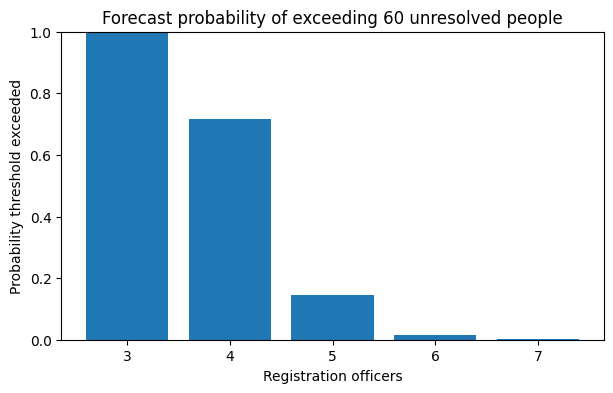

In [125]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    backlog_risk_display["officers"],
    backlog_risk_display["probability_reception_capacity_exceeded"],
)
ax.set_xlabel("Registration officers")
ax.set_ylabel("Probability threshold exceeded")
ax.set_title("Forecast probability of exceeding 60 unresolved people")
ax.set_ylim(0, 1)
plt.show()

The bar chart gives the main decision signal: how often each staffing option crosses the threshold.

But a probability alone does not show how backlog accumulates day by day. For that, we also look at backlog trajectories.

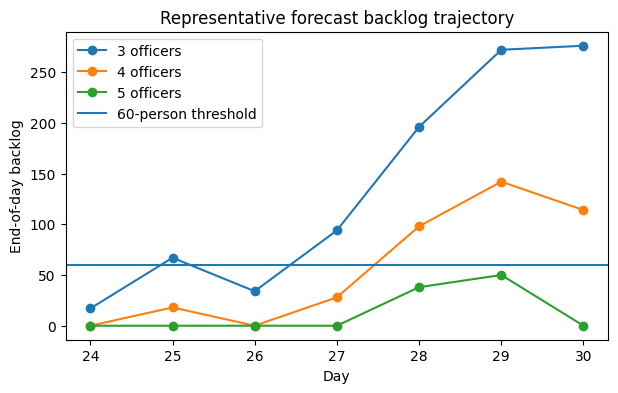

In [126]:
representative_backlog_trajectories = forecast_days_24_30_backlog.loc[
    (forecast_days_24_30_backlog["simulation_id"] == representative_simulation_id)
    & (forecast_days_24_30_backlog["officers"].isin([3, 4, 5]))
].copy()

fig, ax = plt.subplots(figsize=(7, 4))
for officers, group in representative_backlog_trajectories.groupby("officers"):
    group = group.sort_values("day")
    ax.plot(group["day"], group["backlog_end"], marker="o", label=f"{officers} officers")

ax.axhline(reception_capacity_threshold, label="60-person threshold")
ax.set_xlabel("Day")
ax.set_ylabel("End-of-day backlog")
ax.set_title("Representative forecast backlog trajectory")
ax.legend()
plt.show()

This visual makes the threshold easier to interpret. The issue is not only whether arrivals are “high.” The issue is whether unresolved cases accumulate faster than the team can clear them.

A staffing option can look acceptable on average but still create periods of overcrowding. That is why operational planning often needs to look beyond median forecasts.

## 13. Humanitarian consequences of backlog

Backlog is not just an administrative delay.

If people remain unresolved at the end of the day, they may need to stay longer at or near the reception point. That creates additional humanitarian consequences: more waiting, more uncertainty, more crowding, and additional material support needs. Since reception points are usually not designed to accommodate people for several days, minimizing backlog is important for avoiding undignified conditions and situations where services are limited or unavailable.

For this exercise, we translate backlog person-days into two simple extended-stay support quantities. A backlog person-day is counted for each unresolved person remaining at the end of a day. For example, if 40 people remain unresolved at the end of one day and 25 remain unresolved at the end of the next day, that creates 65 backlog person-days. This is a simplified way to represent people who may need additional support while waiting:

In [127]:
water_litres_per_backlog_person_day = 12
food_units_per_backlog_person_day = 1

extended_stay_assumptions = pd.DataFrame(
    {
        "Assumption": ["Additional water", "Additional food"],
        "Value": [
            "12 litres/backlog person-day",
            "1 ration unit/backlog person-day",
        ],
    }
)

extended_stay_assumptions.style.hide(axis="index")

Assumption,Value
Additional water,12 litres/backlog person-day
Additional food,1 ration unit/backlog person-day


These quantities are not meant to replace full sectoral planning standards. They are a simple way to show that a registration bottleneck can create needs beyond the initial arrival-day response.

In [128]:
extended_stay_needs_by_staffing = summarize_extended_stay_needs_by_staffing(
    forecast_days_24_30_backlog_risk,
    water_litres_per_backlog_person_day=water_litres_per_backlog_person_day,
    food_units_per_backlog_person_day=food_units_per_backlog_person_day,
)

extended_stay_needs_display = (
    extended_stay_needs_by_staffing
    .rename(
        columns={
            "officers": "Officers",
            "median_backlog_person_days": "Median backlog person-days",
            "p90_backlog_person_days": "90th pct. backlog person-days",
            "median_extended_stay_water_litres": "Median extra water litres",
            "p90_extended_stay_water_litres": "90th pct. extra water litres",
            "median_extended_stay_food_units": "Median extra food units",
            "p90_extended_stay_food_units": "90th pct. extra food units",
        }
    )
    [
        [
            "Officers",
            "Median backlog person-days",
            "90th pct. backlog person-days",
            "Median extra water litres",
            "90th pct. extra water litres",
            "Median extra food units",
            "90th pct. extra food units",
        ]
    ]
    .round(1)
)

extended_stay_needs_display.style.hide(axis="index")

Officers,Median backlog person-days,90th pct. backlog person-days,Median extra water litres,90th pct. extra water litres,Median extra food units,90th pct. extra food units
3,1106.500000,1647.000000,13278.000000,19764.000000,1106.500000,1647.000000
4,313.000000,779.000000,3756.000000,9348.000000,313.000000,779.000000
5,31.000000,159.000000,372.000000,1908.000000,31.000000,159.000000
6,0.000000,30.000000,0.000000,360.000000,0.000000,30.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


The pattern is straightforward. Lower staffing levels do not only increase the probability of overcrowding. They also increase the expected amount of additional support required because unresolved cases persist across days.

We now reveal the actual final week of arrivals.

In [129]:
actual_days_24_30 = scenario.loc[
    scenario["day"].between(24, 30),
    ["day", "arrivals"],
].copy().reset_index(drop=True)
actual_total_24_30 = int(actual_days_24_30["arrivals"].sum())
assert actual_total_24_30 == 778

actual_days_24_30.rename(columns={"day": "Day", "arrivals": "Arrivals"}).style.hide(axis="index")

Day,Arrivals
24,121
25,123
26,121
27,114
28,96
29,111
30,92


In [130]:
realised_backlog_rows = []
for officers in staffing_options:
    realised_backlog = calculate_daily_backlog(
        actual_days_24_30,
        officers=officers,
        initial_backlog=initial_backlog,
        reception_capacity_threshold=reception_capacity_threshold,
    )
    realised_backlog_rows.append(
        {
            "officers": officers,
            "daily_registration_capacity": calculate_daily_registration_capacity(officers=officers),
            "peak_backlog": realised_backlog["backlog_end"].max(),
            "final_backlog": realised_backlog["backlog_end"].iloc[-1],
            "backlog_person_days": realised_backlog["backlog_end"].sum(),
            "days_exceeding_60_person_threshold": int(realised_backlog["reception_capacity_exceeded"].sum()),
            "ever_exceeded": bool(realised_backlog["reception_capacity_exceeded"].any()),
        }
    )

realised_backlog_summary = pd.DataFrame(realised_backlog_rows)
realised_backlog_summary.rename(
    columns={
        "officers": "Officers",
        "daily_registration_capacity": "Daily registration capacity",
        "peak_backlog": "Peak backlog",
        "final_backlog": "Final backlog",
        "backlog_person_days": "Backlog person-days",
        "days_exceeding_60_person_threshold": "Days above 60-person threshold",
        "ever_exceeded": "Ever exceeded",
    }
).style.hide(axis="index")

Officers,Daily registration capacity,Peak backlog,Final backlog,Backlog person-days,Days above 60-person threshold,Ever exceeded
3,96,110,106,560,5,True
4,128,0,0,0,0,False
5,160,0,0,0,0,False
6,192,0,0,0,0,False
7,224,0,0,0,0,False


The actual final week was gentler than the cautious forecast. The actual total was 778 arrivals, below the forecast median for days 24–30.

In the realised backlog table, backlog person-days again means the sum of unresolved end-of-day backlog across the week.

In hindsight, **4 officers** would have been enough to avoid backlog in the realised final week. But that was not known at the time of planning.

The following chart combines actual daily arrivals, daily registration capacity, and the cumulative unresolved backlog that would have built up with 3 officers. It shows how repeated days above 3-officer capacity would have caused backlog to accumulate, while 4-officer capacity was enough for the realised final week.

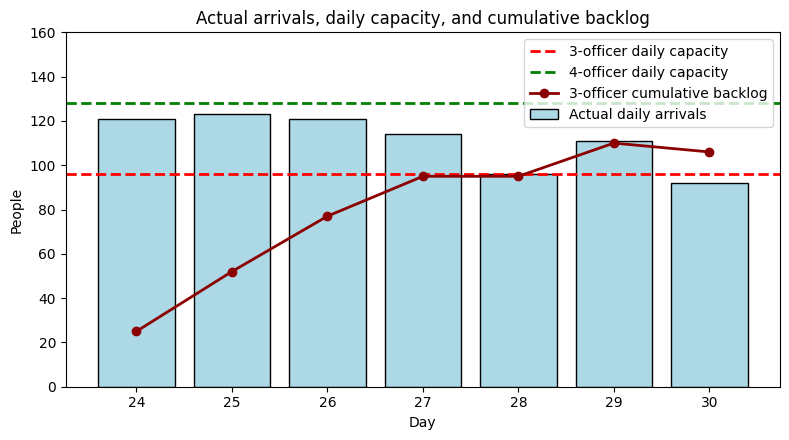

In [131]:
actual_days_24_30_display = actual_days_24_30.copy()

capacity_3_officers = calculate_daily_registration_capacity(officers=3)
capacity_4_officers = calculate_daily_registration_capacity(officers=4)

realised_backlog_3_officers = calculate_daily_backlog(
    actual_days_24_30,
    officers=3,
    initial_backlog=initial_backlog,
    reception_capacity_threshold=reception_capacity_threshold,
)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(
    actual_days_24_30_display["day"],
    actual_days_24_30_display["arrivals"],
    color="lightblue",
    edgecolor="black",
    label="Actual daily arrivals",
)

ax.axhline(
    capacity_3_officers,
    color="red",
    linestyle="--",
    linewidth=2,
    label="3-officer daily capacity",
)

ax.axhline(
    capacity_4_officers,
    color="green",
    linestyle="--",
    linewidth=2,
    label="4-officer daily capacity",
)

ax.plot(
    realised_backlog_3_officers["day"],
    realised_backlog_3_officers["backlog_end"],
    color="darkred",
    marker="o",
    linewidth=2,
    label="3-officer cumulative backlog",
)

ax.set_xlabel("Day")
ax.set_ylabel("People")
ax.set_title("Actual arrivals, daily capacity, and cumulative backlog")
ax.set_ylim(
    0,
    max(
        actual_days_24_30_display["arrivals"].max(),
        capacity_4_officers,
        realised_backlog_3_officers["backlog_end"].max(),
    )
    * 1.25,
)

ax.legend(loc="upper right")
plt.tight_layout()

The forecast-based risk table told a different planning story before the reveal: 3 officers were clearly insufficient, 4 officers carried substantial overcrowding risk, 5 officers looked more tolerable, and 6 or more officers were more robust.

This is the operational lesson.

Preparedness decisions are made before the outcome is known. A cautious plan may look excessive in hindsight if the situation moderates. But under-preparation can produce backlog, overcrowding, and additional humanitarian support needs if the upper tail materialises.

The purpose of probabilistic planning is not to predict one exact future. It is to make the consequences of uncertainty visible enough for decision-makers to choose a tolerable level of risk.

# Part IV — Final Synthesis and Operational Interpretation

The notebook has now followed one synthetic arrival episode from the first limited observations through updated forecasts, preparedness estimates, registration-capacity analysis, backlog risk and final realised outcomes.

The purpose of this final part is not to add another forecasting model. It is to step back and interpret what the exercise showed.

The central lesson is simple:

**A forecast becomes operationally useful when it helps decision-makers compare response options against explicit risks and consequences.**

## 14. Main lessons from the scenario

The scenario showed several linked lessons.

First, forecasts need to be updated as new information arrives. The first mean-based forecast was transparent, but it quickly became outdated when the arrival level changed.

Second, uncertainty matters. A single forecast number can hide the upper-tail cases that are most relevant for preparedness. This is why the notebook moved from point forecasts to simulated forecast distributions.

Third, forecast uncertainty only becomes operationally concrete when it is translated into response quantities and capacity risk. It is useful to estimate water, food, protection and information-provision workload, medical readiness and registration workload. But the sharper operational question is whether daily capacity is enough to prevent unresolved cases from accumulating.

Fourth, the same staffing level does not carry the same risk in every decision context. Staffing risk depends on the forecast distribution available at the time, the length of the planning horizon and the operational threshold being used.

To make this visible, we compare two prospective decision moments:

In [132]:
prospective_comparison_explanation = pd.DataFrame(
    {
        "Planning context": [
            "Surge forecast, days 13–18",
            "Partial-stabilisation forecast, days 24–30",
        ],
        "forecast_issued": [
            "after day 12",
            "after day 23",
        ],
    }
)

prospective_comparison_explanation.rename(columns={"forecast_issued": "Forecast issued"}).style.hide(axis="index")

Planning context,Forecast issued
"Surge forecast, days 13–18",after day 12
"Partial-stabilisation forecast, days 24–30",after day 23


Both comparisons use forecast simulations available before the relevant period, not realised arrivals viewed in hindsight.

In [133]:
# Compare the same staffing options across two prospective forecast periods.
part_iv_periods = [
    {
        "phase": "Surge forecast, days 13–18",
        "simulations": updated_negative_binomial_simulations,
        "horizon_days": 6,
    },
    {
        "phase": "Partial-stabilisation forecast, days 24–30",
        "simulations": forecast_days_24_30_simulations,
        "horizon_days": 7,
    },
]

part_iv_comparison_frames = []
for period in part_iv_periods:
    period_backlog = simulate_backlog_by_staffing(
        period["simulations"],
        staffing_options=staffing_options,
        initial_backlog=initial_backlog,
        reception_capacity_threshold=reception_capacity_threshold,
    )
    period_risk = summarize_backlog_risk(period_backlog)
    period_display = period_risk.loc[
        :,
        [
            "officers",
            "daily_registration_capacity",
            "probability_reception_capacity_exceeded",
            "p90_backlog_person_days",
        ],
    ].copy()
    period_display.insert(0, "Planning context", period["phase"])
    period_display["p90_backlog_person_days_per_planning_day"] = (
        period_display["p90_backlog_person_days"] / period["horizon_days"]
    )
    part_iv_comparison_frames.append(period_display)

part_iv_phase_comparison = pd.concat(part_iv_comparison_frames, ignore_index=True)

part_iv_phase_comparison.round(
    {
        "probability_reception_capacity_exceeded": 3,
        "p90_backlog_person_days": 1,
        "p90_backlog_person_days_per_planning_day": 1,
    }
).rename(
    columns={
        "officers": "Officers",
        "daily_registration_capacity": "Daily registration capacity",
        "probability_reception_capacity_exceeded": "Probability threshold exceeded",
        "p90_backlog_person_days": "90th pct. backlog person-days",
        "p90_backlog_person_days_per_planning_day": "90th pct. backlog person-days/day",
    }
).style.hide(axis="index")

Planning context,Officers,Daily registration capacity,Probability threshold exceeded,90th pct. backlog person-days,90th pct. backlog person-days/day
"Surge forecast, days 13–18",3,96,0.934000,1014.000000,169.000000
"Surge forecast, days 13–18",4,128,0.418000,398.000000,66.300000
"Surge forecast, days 13–18",5,160,0.086000,87.100000,14.500000
"Surge forecast, days 13–18",6,192,0.015000,20.000000,3.300000
"Surge forecast, days 13–18",7,224,0.002000,0.000000,0.000000
"Partial-stabilisation forecast, days 24–30",3,96,0.998000,1647.000000,235.300000
"Partial-stabilisation forecast, days 24–30",4,128,0.718000,779.000000,111.300000
"Partial-stabilisation forecast, days 24–30",5,160,0.146000,159.000000,22.700000
"Partial-stabilisation forecast, days 24–30",6,192,0.016000,30.000000,4.300000
"Partial-stabilisation forecast, days 24–30",7,224,0.001000,0.000000,0.000000


The comparison shows why staffing decisions should not be based only on phase labels.

The later period is described as partial stabilisation, but the forecast available after day 23 still implied substantial operational risk. Under an illustrative 10% tolerance for exceeding the 60-person reception-capacity threshold, 5 officers were below the risk tolerance for the surge-period forecast, but not for the partial-stabilisation forecast.

This does not mean the later period was “worse” in a simple narrative sense. It means that the decision-relevant risk depends on the full forecast distribution, the planning horizon and the operational threshold.

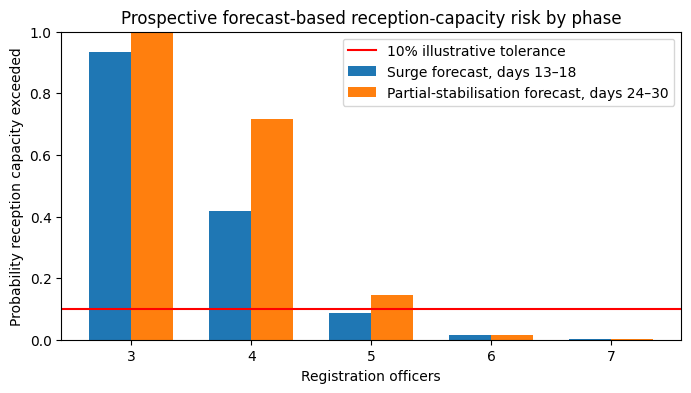

In [134]:
part_iv_chart_data = part_iv_phase_comparison.copy()
part_iv_phases = part_iv_chart_data["Planning context"].drop_duplicates().tolist()
part_iv_officers = sorted(part_iv_chart_data["officers"].unique())
bar_width = 0.35
x_positions = range(len(part_iv_officers))

fig, ax = plt.subplots(figsize=(8, 4))
for index, phase in enumerate(part_iv_phases):
    phase_data = part_iv_chart_data.loc[
        part_iv_chart_data["Planning context"] == phase
    ].set_index("officers")
    offsets = [position + (index - 0.5) * bar_width for position in x_positions]
    ax.bar(
        offsets,
        phase_data.loc[part_iv_officers, "probability_reception_capacity_exceeded"],
        width=bar_width,
        label=phase,
    )

ax.set_xticks(list(x_positions))
ax.set_xticklabels(part_iv_officers)
ax.set_xlabel("Registration officers")
ax.set_ylabel("Probability reception capacity exceeded")
ax.set_title("Prospective forecast-based reception-capacity risk by phase")
ax.set_ylim(0, 1)
ax.axhline(0.10, color="red", label="10% illustrative tolerance")
ax.legend()
plt.show()

The chart gives the final comparative message: the same staffing option can sit in different risk positions depending on the decision point. A staffing plan should therefore be phase-aware, but also forecast-aware.

## 15. What the models did and did not solve

Each model or calculation in the notebook had a specific role. None of them solved the whole operational problem on its own.

The early mean baseline was useful because it was simple and transparent. It showed what a first forecast might look like when only a few days of arrivals are visible. But it failed once the arrival level changed sharply.

The Poisson simulation added uncertainty around the early estimated level. That helped show how much random variation might be expected if the early level continued. But it did not solve the changing-intensity problem. Adding randomness around the wrong level still leaves the forecast structurally behind the situation.

The Negative Binomial comparison widened the upper tail around an updated level. That was useful for representing greater variability and upper-tail risk. But it was not a solution to trend, escalation or phase change. It did not make the model “true.” It only represented a different uncertainty assumption.

The cautious later forecast avoided relaxing too quickly after a volatile period. That is a defensible preparedness posture. But it also meant the forecast could be conservative if the situation began to moderate.

The backlog model translated arrival uncertainty into operational consequences. It showed how daily capacity limits can turn arrival pressure into unresolved cases, reception-capacity exceedance and additional extended-stay support needs. But it also depended on simplified assumptions about registration time, staffing capacity and reception thresholds.

The point is not that one model is the answer. The point is that each layer answers a different question:

```text
arrival forecast → what might happen next?
preparedness translation → what should be ready?
capacity model → can the operation process people in time?
backlog consequences → what happens if it cannot?
```

## 16. How to use this kind of workflow in real operations

In a real operation, this kind of workflow would need better data, local standards, operational judgement and continuous revision. The notebook is only a simplified demonstration.

Still, the basic structure is transferable:

1. Define the decision point.
2. Separate what is already observed from what is still uncertain.
3. Update the forecast as new observations arrive.
4. Use probabilistic ranges, not only point forecasts.
5. Translate arrival forecasts into preparedness quantities.
6. Compare staffing or response options against explicit risk thresholds.
7. Monitor outcomes and revise the assumptions.

The risk threshold should be visible. For example, this notebook used a 10% illustrative tolerance for the probability of exceeding the 60-person reception-capacity threshold. That is not a universal humanitarian standard. It is a policy assumption for the exercise.

A real operation might choose a different tolerance depending on mandate, protection risks, site conditions, contingency capacity, available staff and resources, and the consequences of under-preparation.

The final lesson is therefore not “use this staffing number” or “use this model.”

The lesson is:

**Make the assumptions visible, update them as the situation changes, and compare decisions against the risks that matter operationally.**

Probabilistic planning does not replace humanitarian judgement. It helps make that judgement more explicit.